In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as pyd
import SimpleITK as sitk
sys.path.insert(0, '../src')

from data.dataset import KneeDataset

In [2]:
mrkr_data_path ='../../../../../Volumes/HDD_02/datasets/emory_mrkr/'
mrkr_data_path = os.path.abspath(mrkr_data_path)
mrkr_tables_path = os.path.join(mrkr_data_path,'tables')
mrkr_lateral_path = os.path.join(mrkr_tables_path, 'MRKR_lateral_image_metadata.csv')

lateral_df = pd.read_csv(mrkr_lateral_path)


In [3]:
lateral_df.head()

,empi_anon,StudyInstanceUID_anon,SeriesInstanceUID_anon,SOPInstanceUID_anon,img_height,img_width,laterality,view_position,horizontal_flip,weight_bearing,...,L_KLG_inference,R_KLG_inference,SeriesDescription,StudyDescription,StudyDate_anon,age_at_exam,dicom_path,is_arthroplasty,mask_path,is_segmented
0,10001182,1.2.849.113972.3.57.1.62631357.20201023.1122916,1.2.840.113570.163246170217.20201019125748437223,1.2.826.0.1.3680043.8.498.40281381358579896373...,2539.0,2079.0,R,L,0.0,1.0,...,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2020-05-24,62,10001182/1.2.849.113972.3.57.1.62631357.202010...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,True
1,10001758,1.2.840.113975.3.59.1.64324621.20210625.1133227,1.2.842.113572.163246212233.20210618135511646926,1.2.826.0.1.3680043.8.498.73756677603175613024...,2589.0,1820.0,R,L,0.0,0.0,...,NaN,NaN,Lateral,XR Knee 3 Views Right Standard Protocol,2021-08-06,41,10001758/1.2.840.113975.3.59.1.64324621.202106...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,False
2,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.25097243441976964330...,1775.0,1059.0,R,L,0.0,0.0,...,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,False
3,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.73980548070501957600...,1771.0,1058.0,L,L,0.0,0.0,...,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...,False,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,False
4,10003180,1.2.845.113979.3.64.1.55016411.20170539.1,1.2.846.113564.1632467445.20170530081259855397,1.2.826.0.1.3680043.8.498.12678074990125916447...,2517.0,1985.0,R,L,0.0,1.0,...,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2017-11-09,67,10003180/1.2.845.113979.3.64.1.55016411.201705...,True,/Volumes/HDD_02/datasets/emory_mrkr/masks/1000...,False


In [4]:
segmented_df = lateral_df.loc[lateral_df.is_segmented]

In [5]:
dcm_paths = segmented_df.dicom_path.to_list()
dcm_paths = [os.path.join(mrkr_data_path,'images', p) for p in dcm_paths]
mask_paths = segmented_df.mask_path.to_list()
laterality = segmented_df.laterality.to_list()

In [26]:
ds = KneeDataset(dcm_paths, mask_paths=mask_paths, laterality=laterality, cache_dir='../cache/segmentations')

for i in range(len(ds)): ds[i]

In [7]:
ds[14]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 True)

In [18]:
imgs[14].replace('npz','dcm')

'1.2.826.0.1.3680043.8.498.10786473178774626473348319331105132028.dcm'

In [28]:
imgs = os.listdir("../cache/segmentations/")

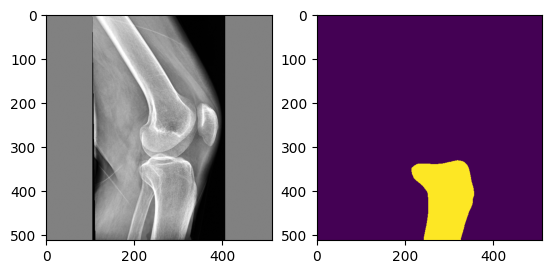

In [29]:
idx = 14

cache_test = np.load(os.path.join("../cache/segmentations/",imgs[idx]))
plt.subplot(121); plt.imshow(cache_test['img'],'gray')
plt.subplot(122); plt.imshow(cache_test['mask'])

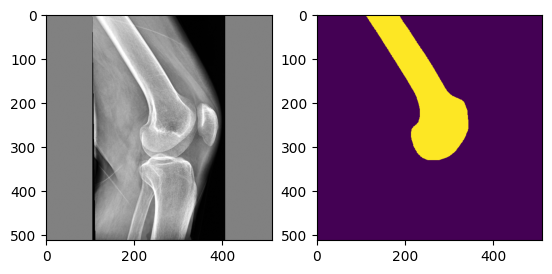

In [15]:
idx = 5

ds_img, ds_mask, _ = ds[idx]
ds_img, ds_mask = ds_img.squeeze(0), ds_mask.squeeze(0)
plt.subplot(121); plt.imshow(ds_img,'gray')
plt.subplot(122); plt.imshow(ds_mask)

In [14]:
testimg = pyd.dcmread(dcm_paths[14]).pixel_array
testmask_read = sitk.ReadImage(mask_paths[14])
testmask = sitk.GetArrayFromImage(testmask_read)

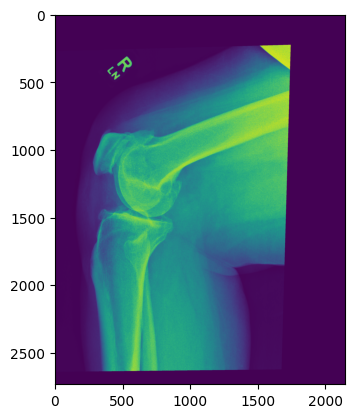

In [15]:
plt.imshow(testimg)

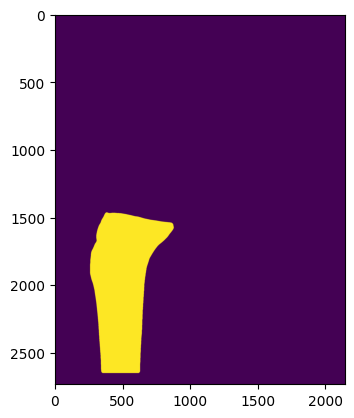

In [16]:
plt.imshow(testmask.squeeze(0) == 1)

In [16]:
import SimpleITK as sitk
mask_nrrd = sitk.ReadImage(mask_paths[5])
mask = sitk.GetArrayFromImage(mask_nrrd)

In [17]:
np.unique(mask.squeeze(0))

array([0, 1, 2, 3, 4], dtype=uint8)

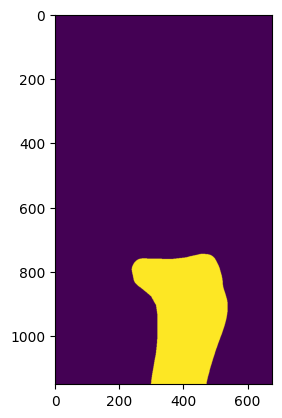

In [20]:
plt.imshow(mask.squeeze(0) == 4)

In [22]:
mask[mask == 1] = 99
mask[mask == 4] = 1
mask[mask == 99] = 4

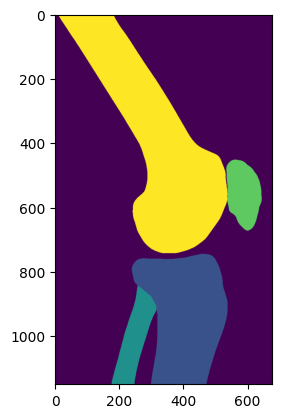

In [23]:
plt.imshow(mask.squeeze(0))

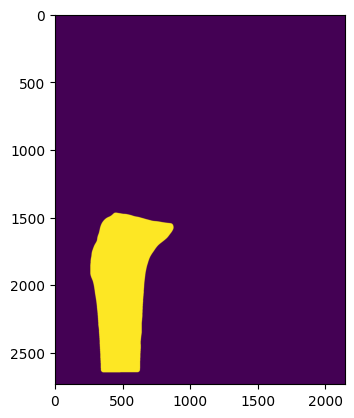

In [ ]:
plt.imshow((mask == 1).squeeze(0))

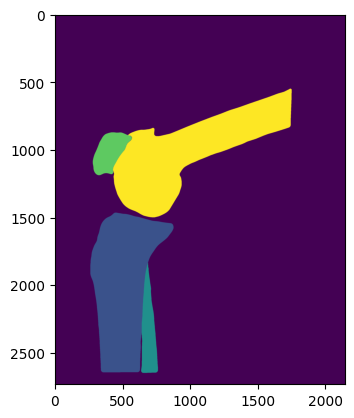

In [ ]:
plt.imshow(mask.squeeze(0))

In [24]:
import shutil

shutil.copy(dcm_paths[5],'.')
shutil.copy(mask_paths[5],'.')

'./1.2.826.0.1.3680043.8.498.10786473178774626473348319331105132028.nrrd'

In [25]:
shutil.copy('./1.2.826.0.1.3680043.8.498.10786473178774626473348319331105132028.nrrd',mask_paths[5])

'/Volumes/HDD_02/datasets/emory_mrkr/masks/37126245/1.2.826.0.1.3680043.8.498.10786473178774626473348319331105132028.nrrd'